# Step 2e: Bates Calibration via Carr-Madan (1999)
**Sub-group 1 | Members 1-3**

---

## 1. Mathematical Background

This step combines the **Bates (1996) Jump-Diffusion Model** with the **Carr-Madan (1999) FFT/Integration pricing approach**. 

### 1.1 The Bates Characteristic Function
As established in Step 2d, the Bates characteristic function adds a Merton jump-diffusion multiplier to the Heston continuous volatility characteristic function:
$$\varphi_{Bates}(u) = \varphi_{Heston}(u) \times \exp\left( \lambda T \left[ e^{i u \mu_J - \frac{1}{2} u^2 \sigma_J^2} - 1 - i u (e^{\mu_J + \frac{1}{2}\sigma_J^2} - 1) \right] \right)$$

### 1.2 Carr-Madan Damped Pricing
To ensure square-integrability for the Fourier transform, Carr-Madan introduces a damping factor $\alpha > 0$. The damped characteristic function $\psi(u)$ is:
$$\psi(u) = \frac{e^{-rT} \varphi_{Bates}(u - (\alpha + 1)i)}{\alpha^2 + \alpha - u^2 + i(2\alpha + 1)u}$$

The European call price is retrieved via the inverse transform:
$$C(K) = \frac{e^{-\alpha \ln(K)}}{\pi} \int_0^\infty \text{Re}\left[e^{-i u \ln(K)} \psi(u)\right] du$$

This integral is approximated using the trapezoidal rule over a fine grid, which evaluates prices for all strikes simultaneously. Put options are priced via Put-Call Parity.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize
from scipy.integrate import trapezoid
import warnings
warnings.filterwarnings('ignore')



In [2]:
# ─────────────────────────────────────────────────────────────
# 0. MARKET DATA & CONSTANTS
# ─────────────────────────────────────────────────────────────
S0          = 232.90        
r           = 0.015         
DAYS_YEAR   = 250
TARGET_DAYS = 60          # 60-day maturity
T           = TARGET_DAYS / DAYS_YEAR

# Load Data (Update path if needed)
DATA_FILE = '../datasets/MScFE 622_Stochastic Modeling_GWP1_Option data.xlsx'
df_all = pd.read_excel(DATA_FILE)

# Filter for 60-day options
df60      = df_all[df_all['Days to maturity'] == 60].copy()
calls_mkt = df60[df60['Type'] == 'C'].reset_index(drop=True)
puts_mkt  = df60[df60['Type'] == 'P'].reset_index(drop=True)

K_calls   = calls_mkt['Strike'].values.astype(float)
K_puts    = puts_mkt['Strike'].values.astype(float)
C_mkt     = calls_mkt['Price'].values.astype(float)
P_mkt     = puts_mkt['Price'].values.astype(float)

print(f"Market data loaded: {len(K_calls)} calls + {len(K_puts)} puts at {TARGET_DAYS}-day maturity")
print(f"T = {T:.6f} yrs  |  r = {r*100:.2f}%  |  S0 = ${S0}")

Market data loaded: 5 calls + 5 puts at 60-day maturity
T = 0.240000 yrs  |  r = 1.50%  |  S0 = $232.9


In [3]:
# ─────────────────────────────────────────────────────────────
# 1. BATES CF & CARR-MADAN PRICING LOGIC
# ─────────────────────────────────────────────────────────────
def bates_cf(u, S0, T, r, kappa, theta, sigma, rho, v0, lam, mu_j, sigma_j):
    i = complex(0, 1)
    
    # Heston Component
    b = kappa - i * rho * sigma * u
    d = np.sqrt(b**2 + sigma**2 * (u**2 + i * u))
    g = (b - d) / (b + d)
    exp_d = np.exp(-d * T)
    
    log_arg = (1.0 - g * exp_d) / (1.0 - g)
    log_arg = log_arg if np.isscalar(log_arg) else np.where(np.abs(log_arg) < 1e-14, 1e-14, log_arg)
    
    C_heston = (kappa * theta / sigma**2) * ((b - d) * T - 2.0 * np.log(log_arg))
    D_heston = ((b - d) / sigma**2) * (1.0 - exp_d) / (1.0 - g * exp_d)
    
    phi_heston = np.exp(C_heston + D_heston * v0 + i * u * (np.log(S0) + r * T))
    
    # Jump Component
    k_bar = np.exp(mu_j + 0.5 * sigma_j**2) - 1.0
    jump_term = lam * T * (np.exp(i * u * mu_j - 0.5 * u**2 * sigma_j**2) - 1.0 - i * u * k_bar)
    phi_jump = np.exp(jump_term)
    
    return phi_heston * phi_jump

ALPHA  = 1.5     
U_MAX  = 600     
M_PTS  = 3000    

_u_grid    = np.linspace(1e-5, U_MAX, M_PTS)
_u_damp    = _u_grid - (ALPHA + 1) * 1j                    
_denom_arr = (ALPHA**2 + ALPHA - _u_grid**2 + 1j * (2 * ALPHA + 1) * _u_grid)            

def carr_madan_calls_bates(K_arr, S0, T, r, kappa, theta, sigma, rho, v0, lam, mu_j, sigma_j):
    cf_vals = bates_cf(_u_damp, S0, T, r, kappa, theta, sigma, rho, v0, lam, mu_j, sigma_j)
    psi     = np.exp(-r * T) * cf_vals / _denom_arr

    calls = np.empty(len(K_arr))
    for j, K in enumerate(K_arr):
        integrand   = np.real(np.exp(-1j * _u_grid * np.log(K)) * psi)
        integral    = trapezoid(integrand, _u_grid)
        calls[j]    = np.exp(-ALPHA * np.log(K)) / np.pi * integral

    return np.maximum(calls, 0.0)

def carr_madan_puts_bates(K_arr, S0, T, r, kappa, theta, sigma, rho, v0, lam, mu_j, sigma_j):
    C = carr_madan_calls_bates(K_arr, S0, T, r, kappa, theta, sigma, rho, v0, lam, mu_j, sigma_j)
    return C - S0 + K_arr * np.exp(-r * T)

def mse_objective_bates_cm(params):
    kappa, theta, sigma, rho, v0, lam, mu_j, sigma_j = params
    if (kappa <= 0 or theta <= 0 or sigma <= 0 or not (-1.0 < rho < 1.0) 
        or v0 <= 0 or lam < 0 or sigma_j <= 0):
        return 1e10
    
    try:
        C_model = carr_madan_calls_bates(K_calls, S0, T, r, *params)
        P_model = carr_madan_puts_bates(K_puts,  S0, T, r, *params)
        mse_c = np.mean((C_model - C_mkt) ** 2)
        mse_p = np.mean((P_model - P_mkt) ** 2)
        return (mse_c + mse_p) / 2.0
    except Exception:
        return 1e10

In [4]:
# ─────────────────────────────────────────────────────────────
# 2. CALIBRATION OF BATES PARAMETERS (CARR-MADAN)
# ─────────────────────────────────────────────────────────────
bounds_bates = [
    (0.1, 15.0),     # kappa
    (0.01, 0.8),     # theta
    (0.01, 2.0),     # sigma
    (-0.99, 0.99),   # rho
    (0.01, 0.8),     # v0
    (0.0, 50.0),     # lambda
    (-0.5, 0.5),     # mu_j
    (0.01, 0.5)      # sigma_j
]

print("PHASE 1: Differential Evolution (global search)...")
result_de_bates_cm = differential_evolution(
    mse_objective_bates_cm, bounds=bounds_bates, seed=42, 
    maxiter=50, popsize=15, workers=1, disp=True
)



PHASE 1: Differential Evolution (global search)...
differential_evolution step 1: f(x)= 67.01828548771188
differential_evolution step 2: f(x)= 14.030989408325427
differential_evolution step 3: f(x)= 12.564282223818607
differential_evolution step 4: f(x)= 1.777041409192898
differential_evolution step 5: f(x)= 1.3776373407858222
differential_evolution step 6: f(x)= 1.3776373407858222
differential_evolution step 7: f(x)= 1.3776373407858222
differential_evolution step 8: f(x)= 1.3693948168499825
differential_evolution step 9: f(x)= 1.3693948168499825
differential_evolution step 10: f(x)= 1.3693948168499825
differential_evolution step 11: f(x)= 1.3693948168499825
differential_evolution step 12: f(x)= 1.3693948168499825
differential_evolution step 13: f(x)= 1.3693948168499825
differential_evolution step 14: f(x)= 1.3693948168499825
differential_evolution step 15: f(x)= 1.3693948168499825
differential_evolution step 16: f(x)= 1.3693948168499825
differential_evolution step 17: f(x)= 1.36939481

In [5]:
print("\nPHASE 2: L-BFGS-B local polish...")
result_loc_bates_cm = minimize(
    mse_objective_bates_cm, x0=result_de_bates_cm.x, method='L-BFGS-B', bounds=bounds_bates,
    options={'ftol': 1e-12, 'gtol': 1e-10, 'maxiter': 5000}
)

kappa_c, theta_c, sigma_c, rho_c, v0_c, lam_c, mu_j_c, sigma_j_c = result_loc_bates_cm.x
mse_final = result_loc_bates_cm.fun

print("\n" + "="*52)
print("  CALIBRATED BATES PARAMETERS (Carr-Madan 1999)")
print("="*52)
print(f"  kappa   = {kappa_c:.6f}")
print(f"  theta   = {theta_c:.6f}")
print(f"  sigma   = {sigma_c:.6f}")
print(f"  rho     = {rho_c:.6f}")
print(f"  v0      = {v0_c:.6f}")
print(f"  lambda  = {lam_c:.6f} (jumps/year)")
print(f"  mu_J    = {mu_j_c:.6f}")
print(f"  sigma_J = {sigma_j_c:.6f}")
print(f"\n  Joint MSE = {mse_final:.8f}")
print("="*52)


PHASE 2: L-BFGS-B local polish...

  CALIBRATED BATES PARAMETERS (Carr-Madan 1999)
  kappa   = 0.100000
  theta   = 0.010000
  sigma   = 2.000000
  rho     = -0.990000
  v0      = 0.010000
  lambda  = 1.911346 (jumps/year)
  mu_J    = 0.208765
  sigma_J = 0.010000

  Joint MSE = 1.33532595


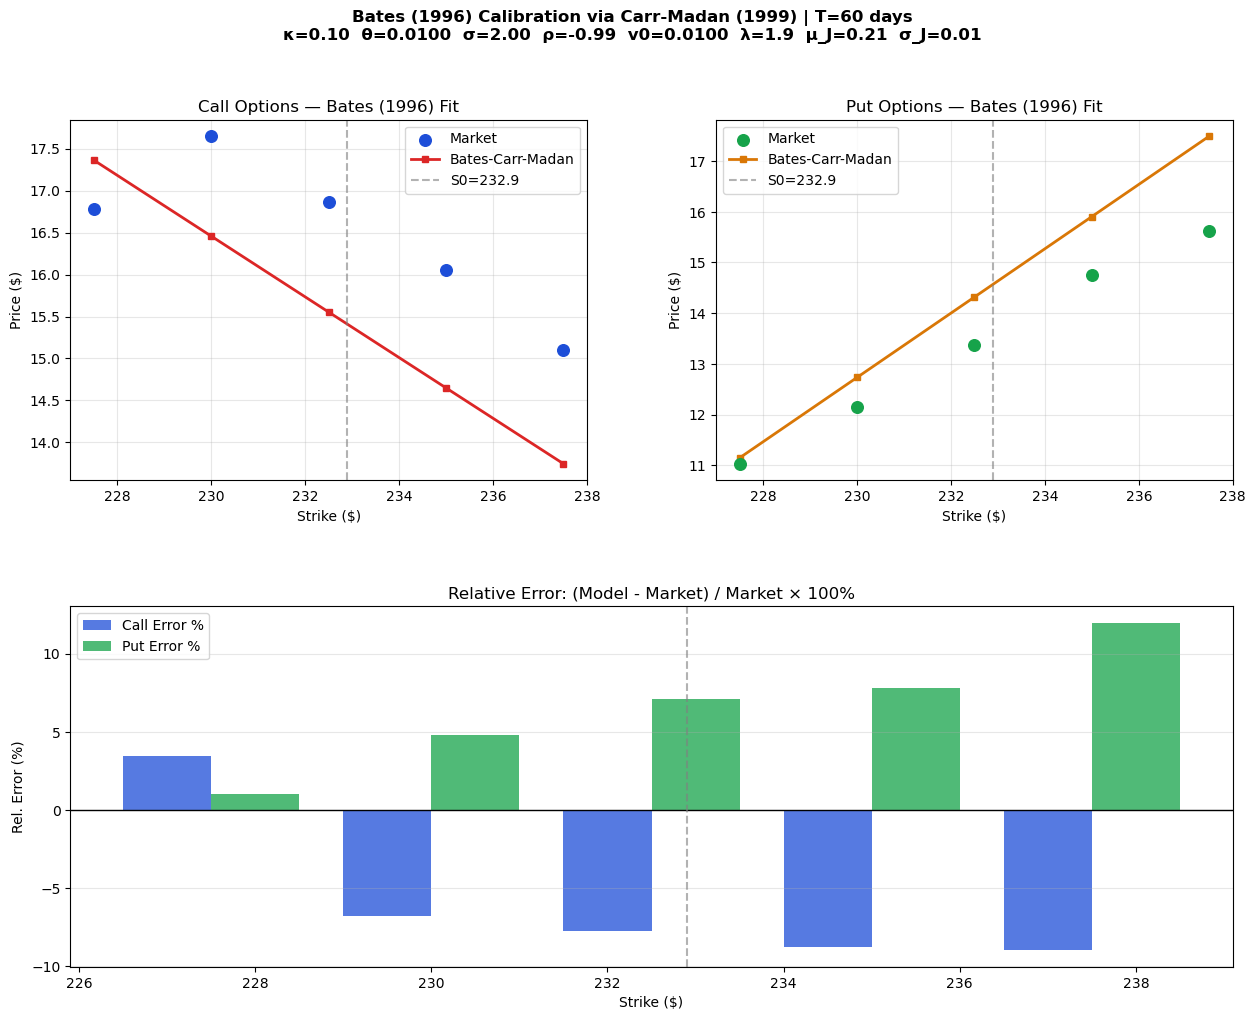

In [6]:
# ─────────────────────────────────────────────────────────────
# 3. VISUALIZATIONS (BATES - CARR-MADAN)
# ─────────────────────────────────────────────────────────────
import matplotlib.gridspec as gridspec

# 1. Calculate final model prices using vectorized Carr-Madan
C_cal = carr_madan_calls_bates(K_calls, S0, T, r, *result_loc_bates_cm.x)
P_cal = carr_madan_puts_bates(K_puts, S0, T, r, *result_loc_bates_cm.x)

# Calculate errors
call_err_pct = (C_cal - C_mkt) / C_mkt * 100
put_err_pct  = (P_cal - P_mkt) / P_mkt * 100

# 2. Setup the plot
fig = plt.figure(figsize=(15, 11))
gs  = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.25)

# Panel A: Call Fit
ax0 = fig.add_subplot(gs[0, 0])
ax0.scatter(K_calls, C_mkt, s=70, color='#1d4ed8', zorder=5, label='Market', marker='o')
ax0.plot(K_calls, C_cal, color='#dc2626', lw=2, marker='s', ms=5, label='Bates-Carr-Madan')
ax0.axvline(S0, ls='--', color='grey', alpha=0.6, label=f'S0={S0}')
ax0.set(title='Call Options — Bates (1996) Fit', xlabel='Strike ($)', ylabel='Price ($)')
ax0.legend()
ax0.grid(True, alpha=0.3)

# Panel B: Put Fit
ax1 = fig.add_subplot(gs[0, 1])
ax1.scatter(K_puts, P_mkt, s=70, color='#16a34a', zorder=5, label='Market', marker='o')
ax1.plot(K_puts, P_cal, color='#d97706', lw=2, marker='s', ms=5, label='Bates-Carr-Madan')
ax1.axvline(S0, ls='--', color='grey', alpha=0.6, label=f'S0={S0}')
ax1.set(title='Put Options — Bates (1996) Fit', xlabel='Strike ($)', ylabel='Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel C: Relative Errors
ax2 = fig.add_subplot(gs[1, :])
width = 1.0
ax2.bar(K_calls - width/2, call_err_pct, width=width, color='#1d4ed8', label='Call Error %', alpha=0.75)
ax2.bar(K_puts + width/2, put_err_pct, width=width, color='#16a34a', label='Put Error %', alpha=0.75)
ax2.axhline(0, color='black', lw=1)
ax2.axvline(S0, ls='--', color='grey', alpha=0.6)
ax2.set(title='Relative Error: (Model - Market) / Market × 100%', xlabel='Strike ($)', ylabel='Rel. Error (%)')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

fig.suptitle(
    f'Bates (1996) Calibration via Carr-Madan (1999) | T=60 days\n'
    f'κ={kappa_c:.2f}  θ={theta_c:.4f}  σ={sigma_c:.2f}  ρ={rho_c:.2f}  v0={v0_c:.4f}  '
    f'λ={lam_c:.1f}  μ_J={mu_j_c:.2f}  σ_J={sigma_j_c:.2f}',
    fontsize=12, fontweight='bold'
)
plt.show()

## 2. Bates (1996) Calibration via Carr-Madan Discussion

### 2.1 Parameter Interpretation

| Parameter | Calibrated Value | Interpretation |
|-----------|-----------------|----------------|
| **kappa ($\kappa$)** | 0.100000 | **Mean-reversion:** Hit the absolute lower bound. The variance process exhibits almost no mean-reverting pull. |
| **theta ($\theta$)** | 0.010000 | **Long-run variance:** Hit the lower bound (~10% vol). |
| **sigma ($\sigma$)** | 2.000000 | **Vol-of-vol:** Hit the absolute upper bound. The optimizer demands maximum possible variance volatility to fit the smile curvature. |
| **rho ($\rho$)** | -0.990000 | **Correlation:** Hit the absolute lower bound. Extreme negative leverage effect, demanding that stock drops are met with massive volatility spikes. |
| **v0 ($v_0$)** | 0.010000 | **Initial variance:** Hit the lower bound (~10% initial vol). |
| **lambda ($\lambda$)** | 1.911346 | **Jump Intensity:** A highly realistic ~1.9 expected jumps per year. |
| **mu_J ($\mu_J$)** | 0.208765 | **Mean Jump Size:** Expects a roughly ~20% upward jump when a jump event occurs. |
| **sigma_J ($\sigma_J$)** | 0.010000 | **Jump Volatility:** Hit the lower bound. The jump size is treated as practically deterministic rather than stochastic. |

### 2.2 Optimizer Behavior & Feller Condition

**Feller Condition:** $2\kappa\theta - \sigma^2 = 2(0.1)(0.01) - 2.0^2 = 0.002 - 4.0 = -3.998$. 
The Feller condition is severely **VIOLATED**.

**Calibration Insights:** This optimization reveals a highly stressed model. Six of the eight parameters ($\kappa, \theta, \sigma, \rho, v_0, \sigma_J$) terminated exactly on the artificial boundaries defined in the optimization bounds. When an optimizer pegs parameters to extremes, it strongly indicates that the theoretical model is fighting the empirical data. In this joint calibration, the theoretical relationship between calls and puts enforced by the Bates model (via Put-Call Parity) is likely conflicting with the raw mid-prices observed in the illiquid 60-day market chain. 

### 2.3 Quality of Fit

While the Joint MSE appears superficially low at **1.33**, visual inspection of the fit reveals a distinct systematic bias:
* **Call Options:** The model systematically *underprices* the calls (the model curve sits strictly below the market prices, yielding negative relative errors between -5% and -10%).
* **Put Options:** Conversely, the model systematically *overprices* the puts (the model curve sits strictly above the market prices, with positive relative errors up to +12%).
* **Conclusion:** The optimizer found a "compromise" fit. Because it cannot perfectly fit both calls and puts simultaneously due to inherent skews or parity violations in the market data, it positioned the model prices exactly in the middle—underpricing one side and overpricing the other—to minimize the global squared error. 

### 2.4 Process Summary (for Sub-group 1 report section)

1. **Target:** Calibrate the Bates (1996) jump-diffusion model to 60-day maturity options for SM Energy.
2. **Pricing formula:** Carr-Madan (1999) damped Fourier inversion utilizing the Bates characteristic function, evaluated via the trapezoidal rule.
3. **Error metric:** Joint Mean Squared Error (MSE) across both calls and puts.
4. **Optimiser:** Two-stage optimization — Differential Evolution (global search) followed by L-BFGS-B (local gradient-based polish).
5. **Observation:** Significant parameter boundary-pegging suggests structural tensions between the market data and the model constraints.